In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/retnolintang/Downloads/Taxi Trip Duration Predictions/Data/Cleaned NYC Taxi Trip Data (2025 Sample).csv')

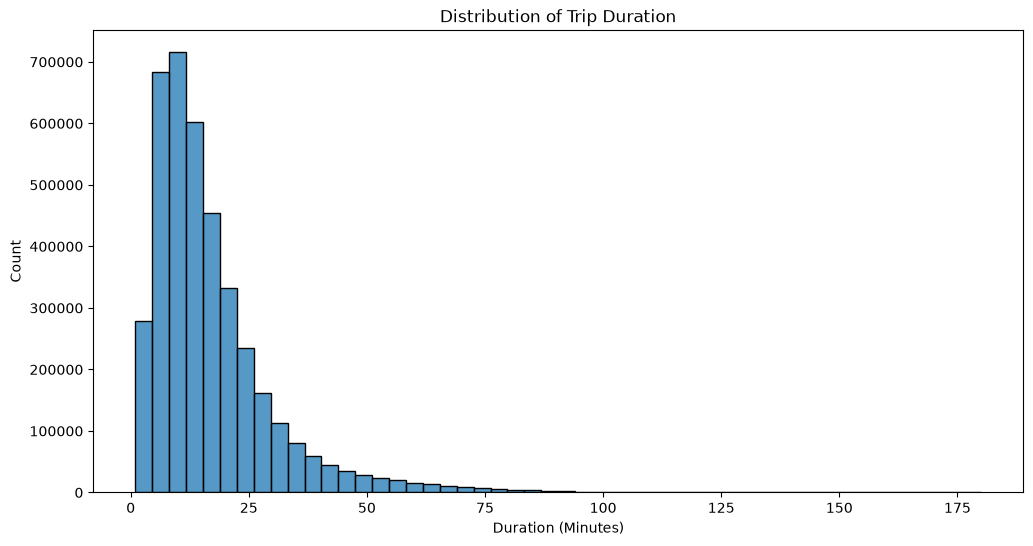

In [2]:
#distribuusi durasi perjalanan
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='duration_min',
    bins=50
)

plt.title('Distribution of Trip Duration')

plt.xlabel('Duration (Minutes)')

plt.show()

In [3]:
df['duration_min'].describe()

count    3.946698e+06
mean     1.697423e+01
std      1.339776e+01
min      1.000000e+00
25%      8.266667e+00
50%      1.338333e+01
75%      2.116667e+01
max      1.799667e+02
Name: duration_min, dtype: float64

### Insight

Mayoritas perjalanan memiliki durasi yang relatif singkat dengan beberapa outlier berdurasi panjang.

### Temuan

- Mayoritas perjalanan memiliki durasi kurang dari **30 menit**.
- Distribusi data **miring ke kanan (right-skewed)**, yang menunjukkan terdapat sejumlah kecil perjalanan dengan durasi yang sangat panjang.
- Ditemukan beberapa **outlier** dengan durasi perjalanan mencapai sekitar **180 menit**.

### Implikasi Bisnis

Sebagian besar perjalanan bersifat jarak pendek hingga menengah, sehingga perusahaan dapat mengoptimalkan rotasi armada dan meningkatkan efisiensi operasional.

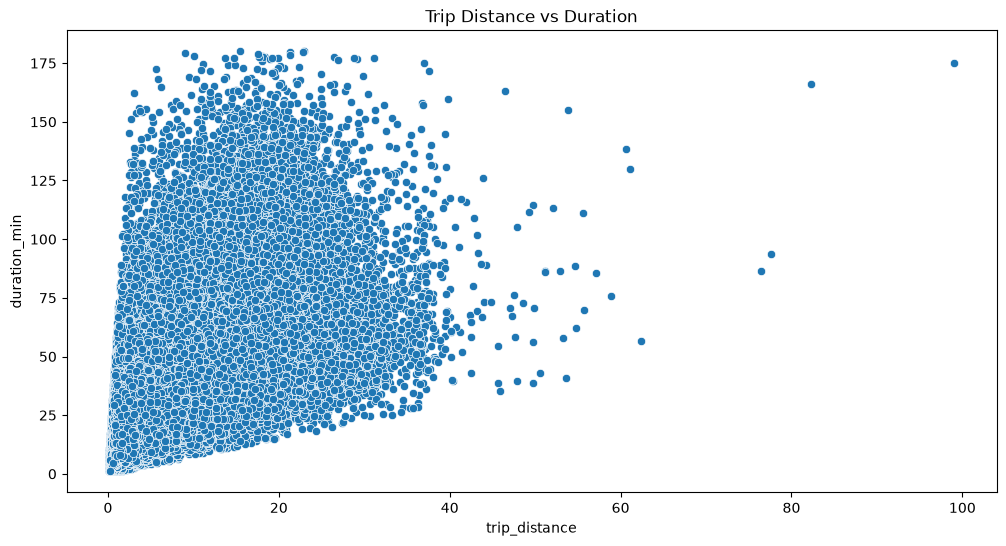

In [4]:
#Trip Distance vs Duration
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='trip_distance',
    y='duration_min'
)

plt.title('Trip Distance vs Duration')

plt.show()

### Insight

Semakin jauh jarak perjalanan, semakin lama durasi perjalanan.

### Temuan

- Terdapat hubungan positif antara `trip_distance` dan `duration_min`.
- Semakin jauh jarak perjalanan, semakin lama durasi perjalanan.
- Ditemukan beberapa anomali, yaitu perjalanan dengan jarak yang relatif pendek tetapi memiliki durasi yang tinggi.

### Implikasi Bisnis

Jarak perjalanan merupakan salah satu faktor utama yang memengaruhi durasi perjalanan dan perlu dipertimbangkan dalam pembangunan model prediksi.

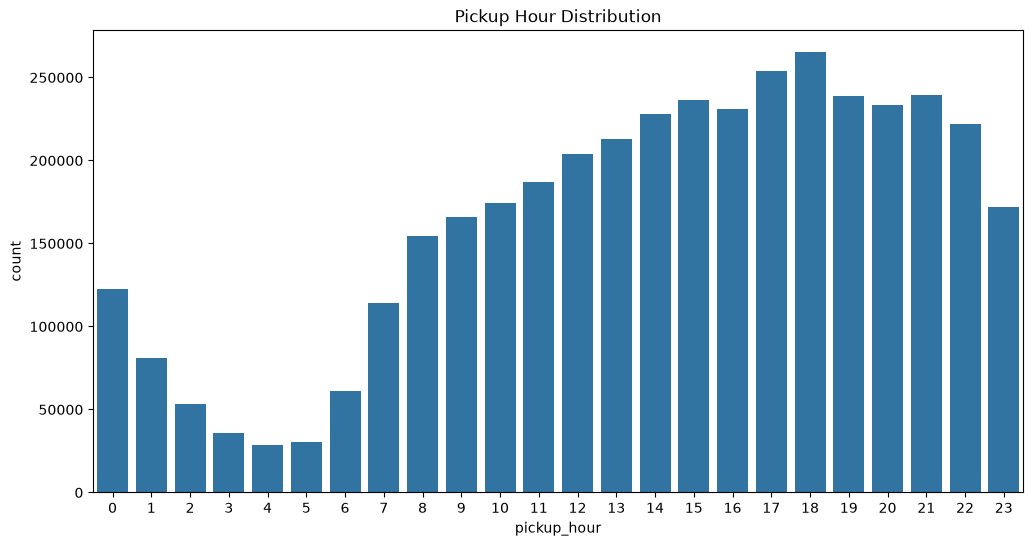

In [5]:
#Pickup Hour Distribution
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='pickup_hour'
)

plt.title('Pickup Hour Distribution')

plt.show()

In [6]:
df['pickup_hour'].value_counts().sort_index()

pickup_hour
0     122780
1      80859
2      53140
3      36055
4      28562
5      30639
6      61227
7     114152
8     154652
9     166238
10    174162
11    186817
12    203629
13    212948
14    227968
15    236521
16    231137
17    253829
18    265056
19    239122
20    233505
21    239301
22    222261
23    172138
Name: count, dtype: int64

### Insight

Jam sibuk dapat diidentifikasi berdasarkan frekuensi perjalanan.

### Temuan

- Frekuensi perjalanan mulai meningkat pada pukul **07.00**.
- Aktivitas perjalanan tertinggi terjadi pada sore hingga malam hari, sekitar pukul **17.00–19.00**.
- Aktivitas perjalanan terendah terjadi pada dini hari, sekitar pukul **03.00–05.00**.

### Implikasi Bisnis

Perusahaan dapat menambah armada pada jam sibuk untuk mengurangi waktu tunggu pelanggan dan meningkatkan efisiensi operasional.

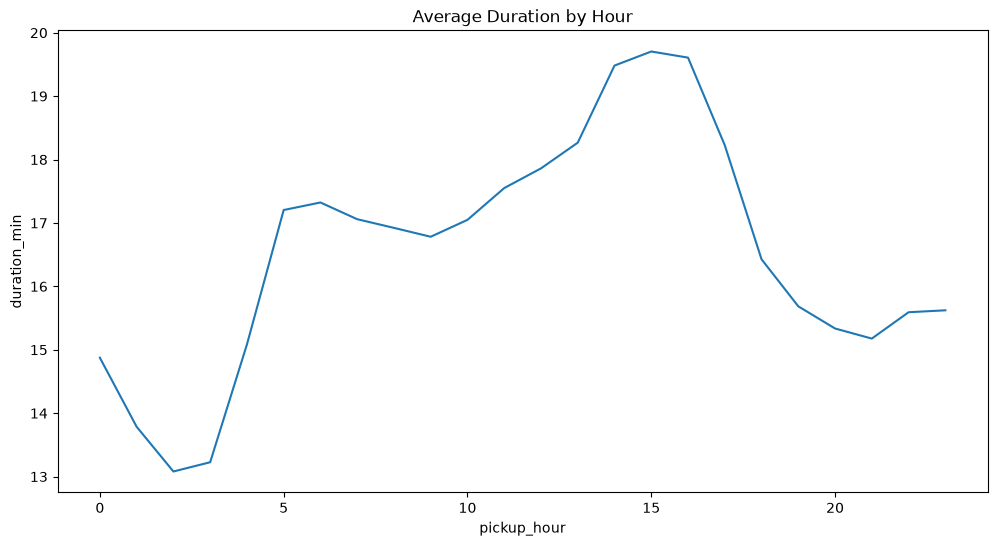

In [7]:
#Average Duration by Hour
hourly = (
    df.groupby('pickup_hour')['duration_min']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly,
    x='pickup_hour',
    y='duration_min'
)

plt.title('Average Duration by Hour')

plt.show()

### Insight

Durasi perjalanan cenderung meningkat pada jam sibuk.

### Temuan

- Durasi perjalanan terpendek terjadi pada dini hari (02.00–03.00), yaitu sekitar **13 menit**.
- Durasi perjalanan terpanjang terjadi pada sore hari (15.00–16.00), yaitu sekitar **19–20 menit**.
- Selisih durasi perjalanan antara jam tersibuk dan jam tersenggang mencapai sekitar **6–7 menit**.

### Implikasi Bisnis

Jam penjemputan (`pickup_hour`) memengaruhi durasi perjalanan dan perlu dimasukkan sebagai fitur utama dalam model prediksi.

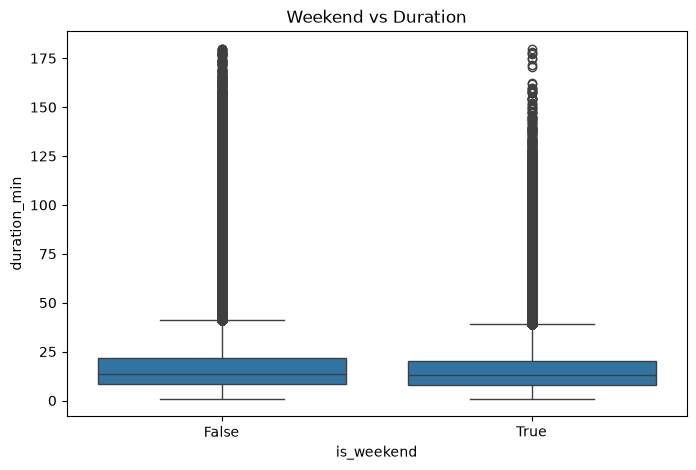

In [8]:
#Weekend vs Weekday
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_weekend',
    y='duration_min'
)

plt.title('Weekend vs Duration')

plt.show()

In [9]:
df.groupby('is_weekend')['duration_min'].mean()

is_weekend
False    17.384177
True     15.982067
Name: duration_min, dtype: float64

### Insight

Durasi perjalanan pada hari kerja dan akhir pekan cenderung serupa.

### Temuan

- Distribusi durasi perjalanan pada hari kerja dan akhir pekan relatif mirip.
- Durasi perjalanan pada akhir pekan cenderung sedikit lebih tinggi.
- Terdapat sejumlah perjalanan dengan durasi ekstrem (outlier) pada kedua kategori.

### Implikasi Bisnis

Variabel `is_weekend` dapat membantu meningkatkan akurasi prediksi karena pola perjalanan pelanggan berbeda antara hari kerja dan akhir pekan.

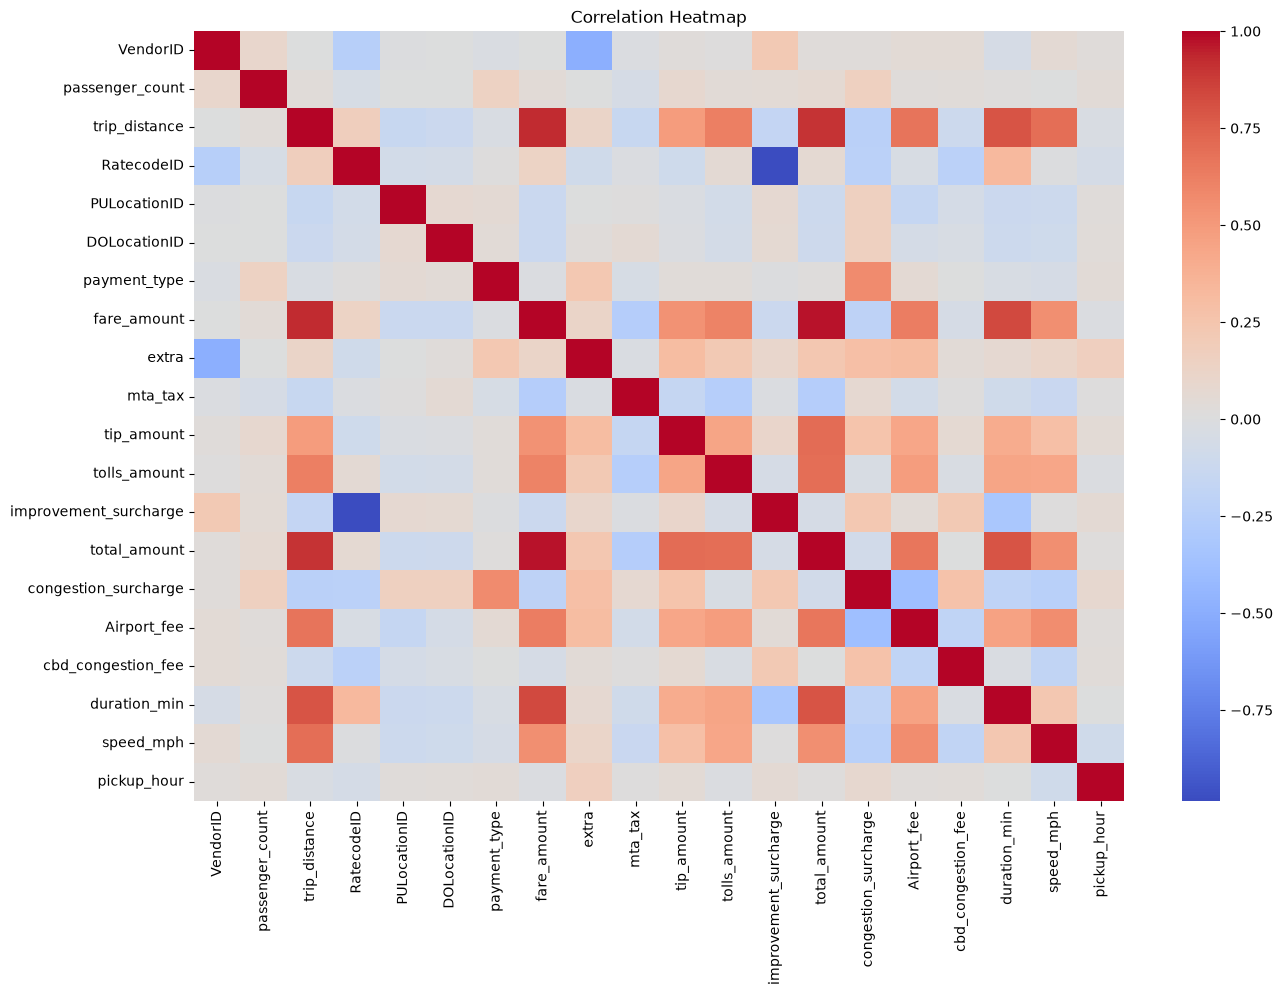

In [10]:
#Correlation Heatmap
numeric = df.select_dtypes(
    include=['int64','float64']
)

corr = numeric.corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight

Beberapa fitur biaya dan jarak berpotensi menjadi prediktor utama durasi perjalanan.

### Temuan

Variabel yang memiliki hubungan paling kuat dengan `duration_min` adalah:

- `trip_distance`
- `fare_amount`
- `total_amount`
- `speed_mph`

Sebagian besar variabel lokasi (`PULocationID` dan `DOLocationID`) memiliki korelasi rendah.

### Implikasi Bisnis

Jarak perjalanan merupakan faktor utama yang memengaruhi durasi perjalanan dan perlu diprioritaskan dalam pembangunan model Machine Learning.